In [1]:
import pickle
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import ttest_ind

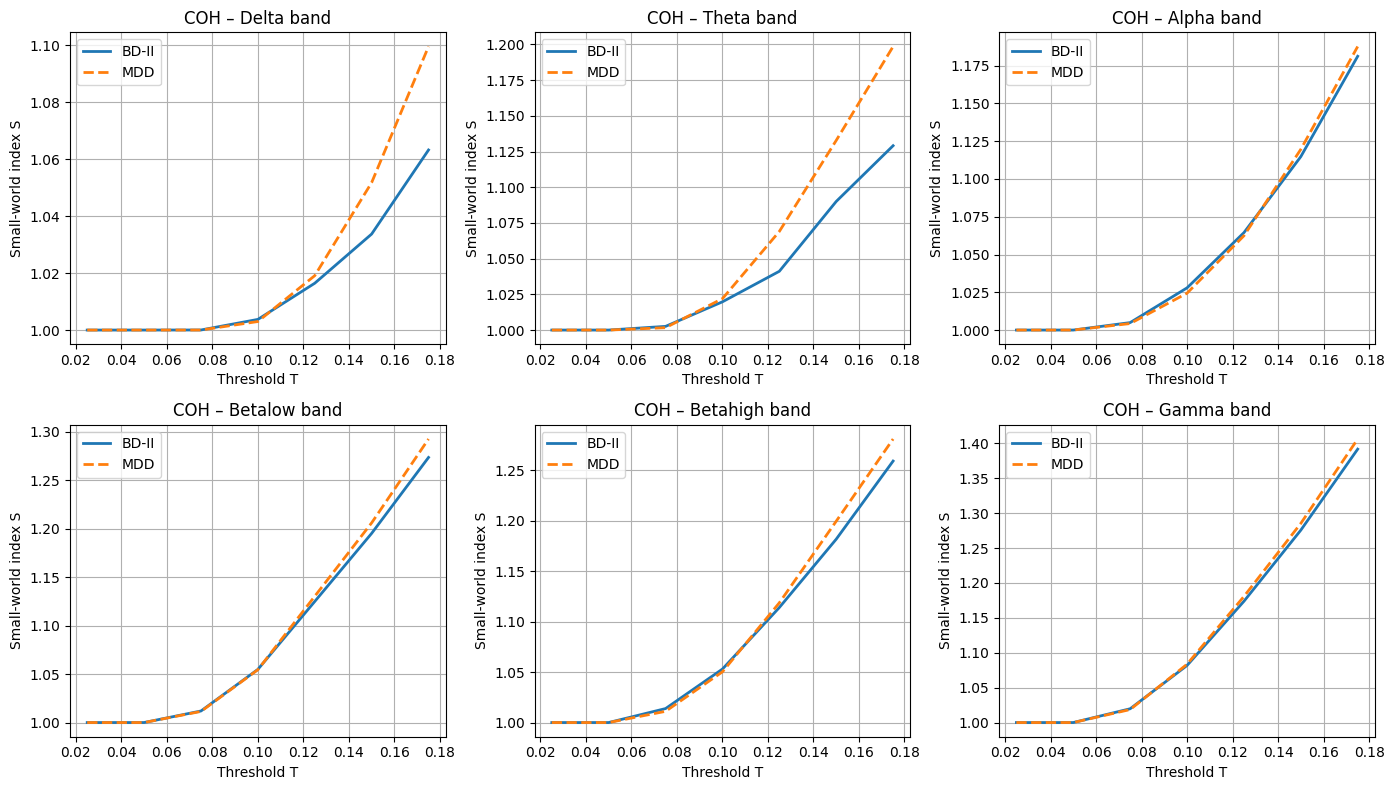

In [ ]:
# 1. 讀取資料函式
def load_pickle(path):
    with open(path, 'rb') as f:
        return pickle.load(f)

# 2. 還原矩陣函式
def vec2mat(vec):
    n_chan = int((1 + np.sqrt(1 + 8 * len(vec))) / 2)
    mat = np.zeros((n_chan, n_chan))
    iu = np.triu_indices(n_chan, 1)
    mat[iu] = vec
    mat[(iu[1], iu[0])] = vec
    return mat

# 3. 參數設定與讀取資料
root = Path("../data")
BD_coh  = load_pickle(root / "COH" / "BD_coh_data.pkl")
MDD_coh = load_pickle(root / "COH" / "MDD_coh_data.pkl")

freqs      = ["delta", "theta", "alpha", "betalow", "betahigh", "gamma"]
thresholds = np.arange(0.025, 0.2, 0.025)
n_rand     = 20

# 4. 計算小世界指數函式（含例外處理）
def compute_group_S(group_coh, freqs, thresholds, n_rand):
    group_S = {band: [] for band in freqs}
    for band in freqs:
        for T in thresholds:
            S_list = []
            for subj in group_coh.values():
                mat = subj[band] if subj[band].ndim == 2 else vec2mat(subj[band])
                A = (mat > T).astype(int)

                # 若無邊緣則跳過
                if A.sum() < 2:
                    continue

                G = nx.from_numpy_array(A)
                C = nx.average_clustering(G)

                lengths = dict(nx.all_pairs_shortest_path_length(G))
                dists = [d for i, dist in lengths.items() for j, d in dist.items() if j > i]
                if not dists:
                    continue
                L = np.mean(dists)

                # 隨機網路計算 Cr, Lr
                m_edges = int(A.sum() / 2)
                Cr_vals, Lr_vals = [], []
                for _ in range(n_rand):
                    G_r = nx.gnm_random_graph(len(A), m_edges)
                    Cr_vals.append(nx.average_clustering(G_r))
                    lengths_r = dict(nx.all_pairs_shortest_path_length(G_r))
                    d_r = [d for i, dist in lengths_r.items() for j, d in dist.items() if j > i]
                    if not d_r:
                        continue
                    Lr_vals.append(np.mean(d_r))

                if not Cr_vals or not Lr_vals:
                    continue

                Cr_mean = np.mean(Cr_vals)
                Lr_mean = np.mean(Lr_vals)
                if Cr_mean == 0 or Lr_mean == 0:
                    continue

                gamma = C / Cr_mean
                lam   = L / Lr_mean
                S_list.append(gamma / lam)

            # 若有有效值則取平均，否則以 NaN 補齊
            if S_list:
                group_S[band].append(np.mean(S_list))
            else:
                group_S[band].append(np.nan)

    return group_S

# 5. 執行計算並繪圖
BD_S  = compute_group_S(BD_coh,  freqs, thresholds, n_rand)
MDD_S = compute_group_S(MDD_coh, freqs, thresholds, n_rand)




In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for ax, band in zip(axes, freqs):
    ax.plot(thresholds, BD_S[band],  label='BD-II',  linewidth=2)
    ax.plot(thresholds, MDD_S[band], linestyle='--', label='MDD', linewidth=2)
    ax.set_title(f'COH – {band.capitalize()} band')
    ax.set_xlabel('Threshold T')
    ax.set_ylabel('Small-world index S')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

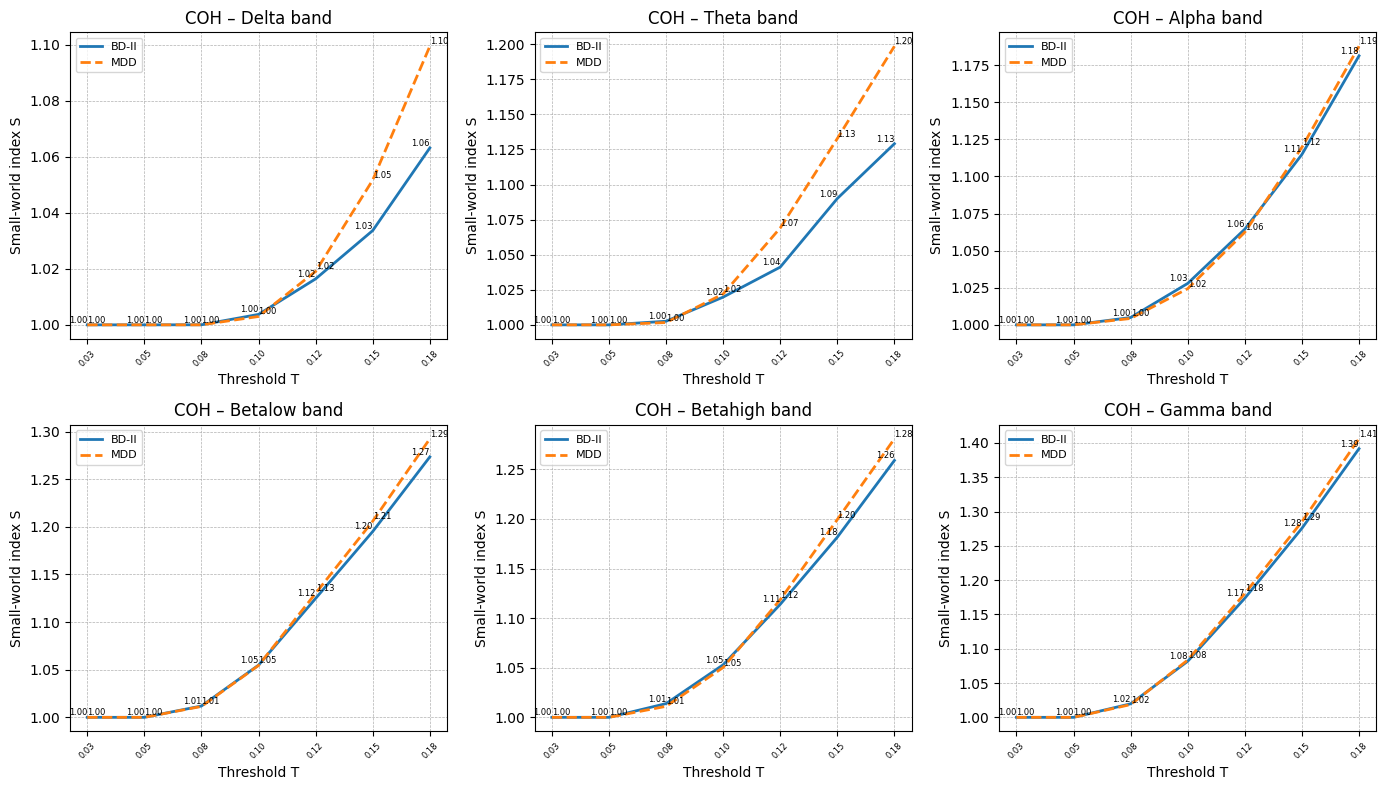

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, band in zip(axes, freqs):
    x = thresholds
    y_bd = BD_S[band]
    y_mdd = MDD_S[band]
    
    # 繪製折線
    ax.plot(x, y_bd, label='BD-II', linewidth=2)
    ax.plot(x, y_mdd, linestyle='--', label='MDD', linewidth=2)
    
    # 設定 x 軸 major ticks 為 thresholds，並顯示上刻度
    ax.set_xticks(x)
    ax.set_xticklabels([f"{t:.2f}" for t in x], rotation=45, fontsize=6)
    ax.minorticks_off()
    
    # 只在 major ticks 畫 grid
    ax.grid(True, which='major', linestyle='--', linewidth=0.5)
    
    # 在每個點上標示數值
    for xi, yi in zip(x, y_bd):
        ax.text(xi, yi, f"{yi:.2f}", fontsize=6, va='bottom', ha='right')
    for xi, yi in zip(x, y_mdd):
        ax.text(xi, yi, f"{yi:.2f}", fontsize=6, va='bottom', ha='left')
    
    ax.set_title(f'COH – {band.capitalize()} band')
    ax.set_xlabel('Threshold T')
    ax.set_ylabel('Small-world index S')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

##### COH

In [4]:
def load_pickle(path):
    with open(path, 'rb') as f:
        return pickle.load(f)


def vec2mat(vec, n_chan):
    mat = np.zeros((n_chan, n_chan))
    iu = np.triu_indices(n_chan, 1)
    mat[iu] = vec
    mat[(iu[1], iu[0])] = vec
    return mat

root      = Path("../data")
BD_coh    = load_pickle(root / "COH" / "BD_coh_data.pkl")
MDD_coh   = load_pickle(root / "COH" / "MDD_coh_data.pkl")
freqs     = ["delta", "theta", "alpha", "betalow", "betahigh", "gamma"]
thresholds= np.arange(0.025, 0.7, 0.025)
n_rand    = 20

In [ ]:


# compute: C, Cr, L, Lr, γ, λ, S
def compute_stage_metrics(group_coh, freqs, thresholds, n_rand):
    n_chan = None
    metrics = {band: {} for band in freqs}
    for band in freqs:
        for T in thresholds:
            C_list = []
            Cr_list= []
            L_list = []
            Lr_list= []
            gamma_list = []
            lam_list   = []
            S_list     = []
            for subj in group_coh.values():
                X = subj[band]
                if X.ndim == 1:
                    # first subject we see, infer n_chan
                    if n_chan is None:
                        n_chan = int((1 + np.sqrt(1 + 8*len(X)))//2)
                    mat = vec2mat(X, n_chan)
                else:
                    mat = X
                    if n_chan is None:
                        n_chan = mat.shape[0]
                A = (mat > T).astype(int)
                if A.sum() < 2:
                    continue

                # 原網路 C, L
                G = nx.from_numpy_array(A)
                C = nx.average_clustering(G)
                dists = []
                for i, dist in nx.all_pairs_shortest_path_length(G):
                    dists.extend([d for j, d in dist.items() if j > i])
                if not dists:
                    continue
                L = np.mean(dists)

                # 隨機網路 Cr, Lr
                m_edges = int(A.sum()/2)
                Cr_subj, Lr_subj = [], []
                for _ in range(n_rand):
                    G_r = nx.gnm_random_graph(n_chan, m_edges)
                    Cr_subj.append(nx.average_clustering(G_r))
                    d_r = []
                    for i, dist in nx.all_pairs_shortest_path_length(G_r):
                        d_r.extend([d for j, d in dist.items() if j > i])
                    if d_r:
                        Lr_subj.append(np.mean(d_r))
                if not Cr_subj or not Lr_subj:
                    continue
                Cr = np.mean(Cr_subj)
                Lr = np.mean(Lr_subj)
                if Cr == 0 or Lr == 0:
                    continue

                gamma = C/Cr
                lam   = L/Lr
                S     = gamma/lam

                # 收集
                C_list.append(C)
                Cr_list.append(Cr)
                L_list.append(L)
                Lr_list.append(Lr)
                gamma_list.append(gamma)
                lam_list.append(lam)
                S_list.append(S)

            metrics[band][T] = {
                'C':    C_list,
                'Cr':   Cr_list,
                'L':    L_list,
                'Lr':   Lr_list,
                'gamma':gamma_list,
                'lam':  lam_list,
                'S':    S_list
            }
    return metrics

metrics_BD  = compute_stage_metrics(BD_coh,  freqs, thresholds, n_rand)
metrics_MDD = compute_stage_metrics(MDD_coh, freqs, thresholds, n_rand)


In [4]:
### save metrics
with open("../result_FA/svalue/COH/metrics_BD.pkl", 'wb') as f:
    pickle.dump(metrics_BD, f)
with open("../result_FA/svalue/COH/metrics_MDD.pkl", 'wb') as f:
    pickle.dump(metrics_MDD, f)

In [2]:
### load metrics
with open("../result_FA/svalue/COH/metrics_BD.pkl", 'rb') as f:
    metrics_BD = pickle.load(f)
with open("../result_FA/svalue/COH/metrics_MDD.pkl", 'rb') as f:
    metrics_MDD = pickle.load(f)


=== Band: delta ===
T=0.025: BD C=1.000,Cr=1.000,L=1.000,Lr=1.000,γ=1.000,λ=1.000,S=1.000 | MDD C=1.000,Cr=1.000,L=1.000,Lr=1.000,γ=1.000,λ=1.000,S=1.000 | t=nan,p=nan
T=0.050: BD C=1.000,Cr=1.000,L=1.000,Lr=1.000,γ=1.000,λ=1.000,S=1.000 | MDD C=1.000,Cr=1.000,L=1.000,Lr=1.000,γ=1.000,λ=1.000,S=1.000 | t=nan,p=nan
T=0.075: BD C=1.000,Cr=1.000,L=1.000,Lr=1.000,γ=1.000,λ=1.000,S=1.000 | MDD C=1.000,Cr=1.000,L=1.000,Lr=1.000,γ=1.000,λ=1.000,S=1.000 | t=0.803,p=0.424
T=0.100: BD C=0.992,Cr=0.989,L=1.011,Lr=1.011,γ=1.004,λ=1.000,S=1.004 | MDD C=0.988,Cr=0.985,L=1.015,Lr=1.015,γ=1.003,λ=1.000,S=1.003 | t=0.371,p=0.711
T=0.125: BD C=0.971,Cr=0.959,L=1.038,Lr=1.041,γ=1.013,λ=0.997,S=1.016 | MDD C=0.947,Cr=0.932,L=1.066,Lr=1.068,γ=1.018,λ=0.999,S=1.019 | t=-0.443,p=0.659
T=0.150: BD C=0.939,Cr=0.915,L=1.082,Lr=1.085,γ=1.031,λ=0.997,S=1.034 | MDD C=0.897,Cr=0.859,L=1.139,Lr=1.141,γ=1.050,λ=0.998,S=1.052 | t=-1.794,p=0.075
T=0.175: BD C=0.910,Cr=0.867,L=1.129,Lr=1.133,γ=1.059,λ=0.996,S=1.064 | M

c:\Users\NESS-Kuan\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


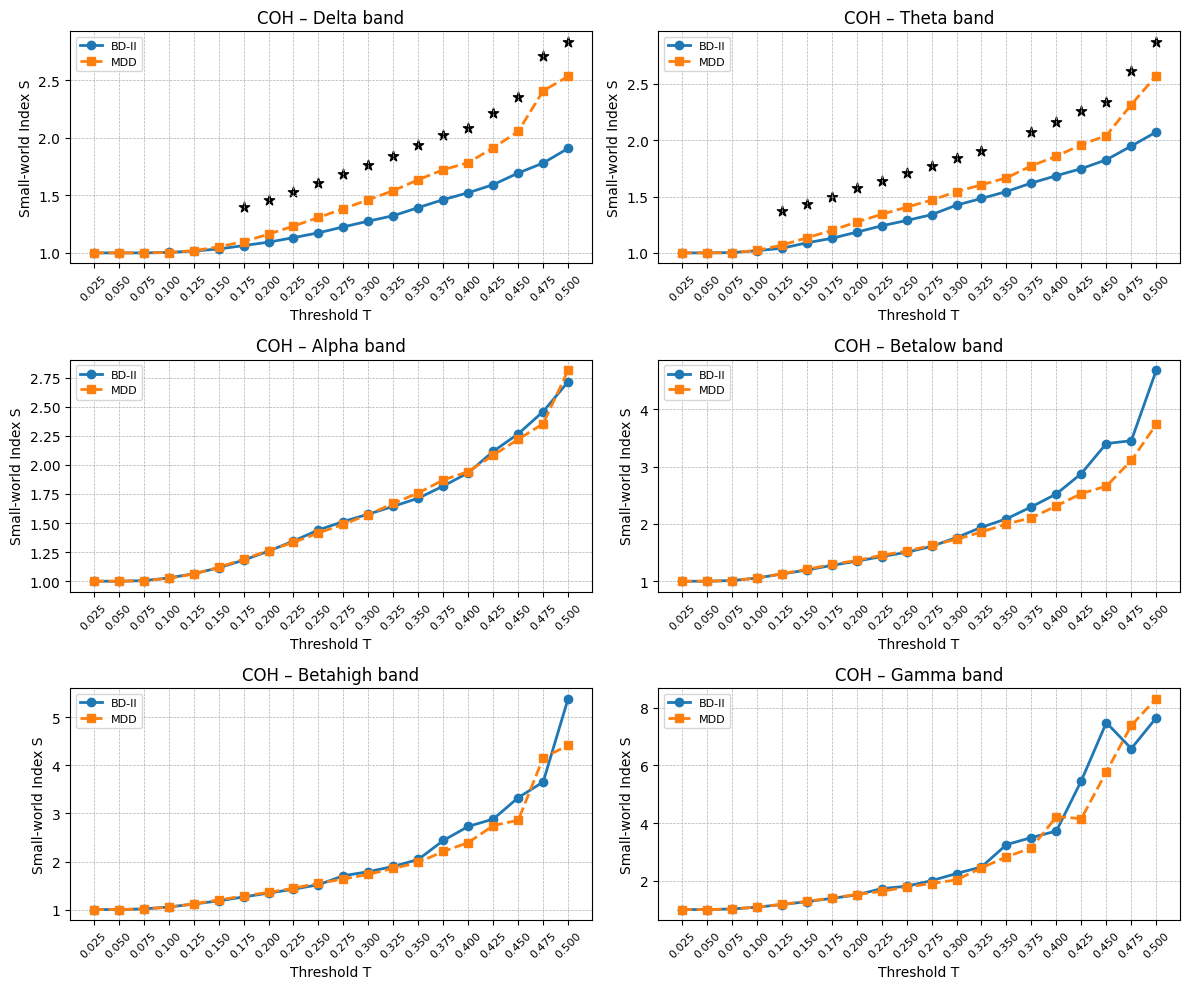

In [5]:
# analysis
summary = {band: {} for band in freqs}
signif  = {band: [] for band in freqs}

for band in freqs:
    print(f"\n=== Band: {band} ===")
    for T in thresholds:
        mb = metrics_BD[band][T]
        mm = metrics_MDD[band][T]
        # 如果任一組無資料，跳過
        if not mb['S'] or not mm['S']:
            summary[band][T] = None
            signif[band].append(False)
            print(f"T={T:.3f}: insufficient data, skipped")
            continue

        # 群組平均
        mC_b = np.mean(mb['C']);   mCr_b = np.mean(mb['Cr'])
        mL_b = np.mean(mb['L']);   mLr_b = np.mean(mb['Lr'])
        mg_b = np.mean(mb['gamma']);  ml_b = np.mean(mb['lam'])
        mS_b = np.mean(mb['S'])

        mC_m = np.mean(mm['C']);   mCr_m = np.mean(mm['Cr'])
        mL_m = np.mean(mm['L']);   mLr_m = np.mean(mm['Lr'])
        mg_m = np.mean(mm['gamma']);  ml_m = np.mean(mm['lam'])
        mS_m = np.mean(mm['S'])

        # t test
        stat, p = ttest_ind(mb['S'], mm['S'], equal_var=False)
        flag = (p < 0.05)
        signif[band].append(flag)


        summary[band][T] = {
            'mean_C_BD':   mC_b,  'mean_Cr_BD':  mCr_b,
            'mean_L_BD':   mL_b,  'mean_Lr_BD':  mLr_b,
            'mean_gamma_BD': mg_b,'mean_lam_BD': ml_b,
            'mean_S_BD':   mS_b,

            'mean_C_MDD':   mC_m,  'mean_Cr_MDD':  mCr_m,
            'mean_L_MDD':   mL_m,  'mean_Lr_MDD':  mLr_m,
            'mean_gamma_MDD': mg_m,'mean_lam_MDD': ml_m,
            'mean_S_MDD':    mS_m,

            't_stat': stat, 'p_val': p
        }


        star = "*" if flag else ""
        print((
            f"T={T:.3f}: "
            f"BD C={mC_b:.3f},Cr={mCr_b:.3f},L={mL_b:.3f},Lr={mLr_b:.3f},"
            f"γ={mg_b:.3f},λ={ml_b:.3f},S={mS_b:.3f} | "
            f"MDD C={mC_m:.3f},Cr={mCr_m:.3f},L={mL_m:.3f},Lr={mLr_m:.3f},"
            f"γ={mg_m:.3f},λ={ml_m:.3f},S={mS_m:.3f} | "
            f"t={stat:.3f},p={p:.3f}{star}"
        ))




# plot
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, band in zip(axes, freqs):
    x      = thresholds[:20]
    y_bd   = [summary[band][T]['mean_S_BD']   if summary[band][T] else np.nan for T in x]
    y_mdd  = [summary[band][T]['mean_S_MDD']  if summary[band][T] else np.nan for T in x]
    sigs   = signif[band]

    ax.plot(x, y_bd,  label='BD-II', linewidth=2, marker='o')
    ax.plot(x, y_mdd, linestyle='--', label='MDD', linewidth=2, marker='s')

    # 標示顯著點（在兩曲線中點做標記）
    for xi, bd_i, mdd_i, sig in zip(x, y_bd, y_mdd, sigs):
        if sig:
            # y_star = 0.5*(bd_i + mdd_i)
            y_star = max(bd_i, mdd_i) + 0.3
            ax.scatter(xi, y_star, marker='*', color='black', s=60)

    ax.set_xticks(x)
    ax.set_xticklabels([f"{t:.3f}" for t in x], rotation=45, fontsize=8)
    ax.grid(True, which='major', linestyle='--', linewidth=0.5)

    # 在每個點上標示數值
    # for xi, yi in zip(x, y_bd):
    #     ax.text(xi, yi, f"{yi:.2f}", fontsize=6, va='bottom', ha='right')
    # for xi, yi in zip(x, y_mdd):
    #     ax.text(xi, yi, f"{yi:.2f}", fontsize=6, va='bottom', ha='left')

    ax.set_title(f'COH – {band.capitalize()} band')
    ax.set_xlabel('Threshold T')
    ax.set_ylabel('Small-world Index S')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


##### PLI

In [6]:
def load_pickle(path):
    with open(path, 'rb') as f:
        return pickle.load(f)

def vec2mat(vec, n_chan):
    mat = np.zeros((n_chan, n_chan))
    iu = np.triu_indices(n_chan, 1)
    mat[iu] = vec
    mat[(iu[1], iu[0])] = vec
    return mat


root       = Path("../data")
BD_pli     = load_pickle(root / "PLI" / "BD_pli_data.pkl")
MDD_pli    = load_pickle(root / "PLI" / "MDD_pli_data.pkl")
freqs      = ["delta", "theta", "alpha", "betalow", "betahigh", "gamma"]
thresholds = np.arange(0.005, 0.4, 0.005)
n_rand     = 20



In [ ]:

# 計算圖論指標：C, Cr, L, Lr, γ, λ, S
def compute_stage_metrics(group_pli, freqs, thresholds, n_rand):
    n_chan = None
    metrics = {band: {} for band in freqs}

    for band in freqs:
        for T in thresholds:
            C_list = []; Cr_list = []
            L_list = []; Lr_list = []
            gamma_list = []; lam_list = []; S_list = []

            for subj in group_pli.values():
                X = subj[band]
                if X.ndim == 1:
                    if n_chan is None:
                        n_chan = int((1 + np.sqrt(1 + 8*len(X)))//2)
                    mat = vec2mat(X, n_chan)
                else:
                    mat = X
                    if n_chan is None:
                        n_chan = mat.shape[0]

                A = (mat > T).astype(int)
                if A.sum() < 2:
                    continue

                # 原網路 C, L
                G = nx.from_numpy_array(A)
                C = nx.average_clustering(G)
                dists = []
                for i, dist in nx.all_pairs_shortest_path_length(G):
                    dists.extend([d for j, d in dist.items() if j > i])
                if not dists:
                    continue
                L = np.mean(dists)

                # 隨機網路 Cr, Lr
                m_edges = int(A.sum() / 2)
                Cr_subj, Lr_subj = [], []
                for _ in range(n_rand):
                    G_r = nx.gnm_random_graph(n_chan, m_edges)
                    Cr_subj.append(nx.average_clustering(G_r))
                    d_r = []
                    for i, dist in nx.all_pairs_shortest_path_length(G_r):
                        d_r.extend([d for j, d in dist.items() if j > i])
                    if d_r:
                        Lr_subj.append(np.mean(d_r))

                if not Cr_subj or not Lr_subj:
                    continue

                Cr = np.mean(Cr_subj)
                Lr = np.mean(Lr_subj)
                if Cr == 0 or Lr == 0:
                    continue

                gamma = C / Cr
                lam   = L / Lr
                S     = gamma / lam

                C_list.append(C)
                Cr_list.append(Cr)
                L_list.append(L)
                Lr_list.append(Lr)
                gamma_list.append(gamma)
                lam_list.append(lam)
                S_list.append(S)

            metrics[band][T] = {
                'C':    C_list,   'Cr':   Cr_list,
                'L':    L_list,   'Lr':   Lr_list,
                'gamma':gamma_list,'lam':  lam_list,
                'S':    S_list
            }

    return metrics


metrics_BD  = compute_stage_metrics(BD_pli,  freqs, thresholds, n_rand)
metrics_MDD = compute_stage_metrics(MDD_pli, freqs, thresholds, n_rand)

KeyboardInterrupt: 

In [ ]:
### save metrics
with open("../result_FA/svalue/PLI/metrics_BD.pkl", 'wb') as f:
    pickle.dump(metrics_BD, f)
with open("../result_FA/svalue/PLI/metrics_MDD.pkl", 'wb') as f:
    pickle.dump(metrics_MDD, f)

In [7]:
### load metrics
with open("../result_FA/svalue/PLI/metrics_BD.pkl", 'rb') as f:
    metrics_BD = pickle.load(f)
with open("../result_FA/svalue/PLI/metrics_MDD.pkl", 'rb') as f:
    metrics_MDD = pickle.load(f)

c:\Users\NESS-Kuan\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


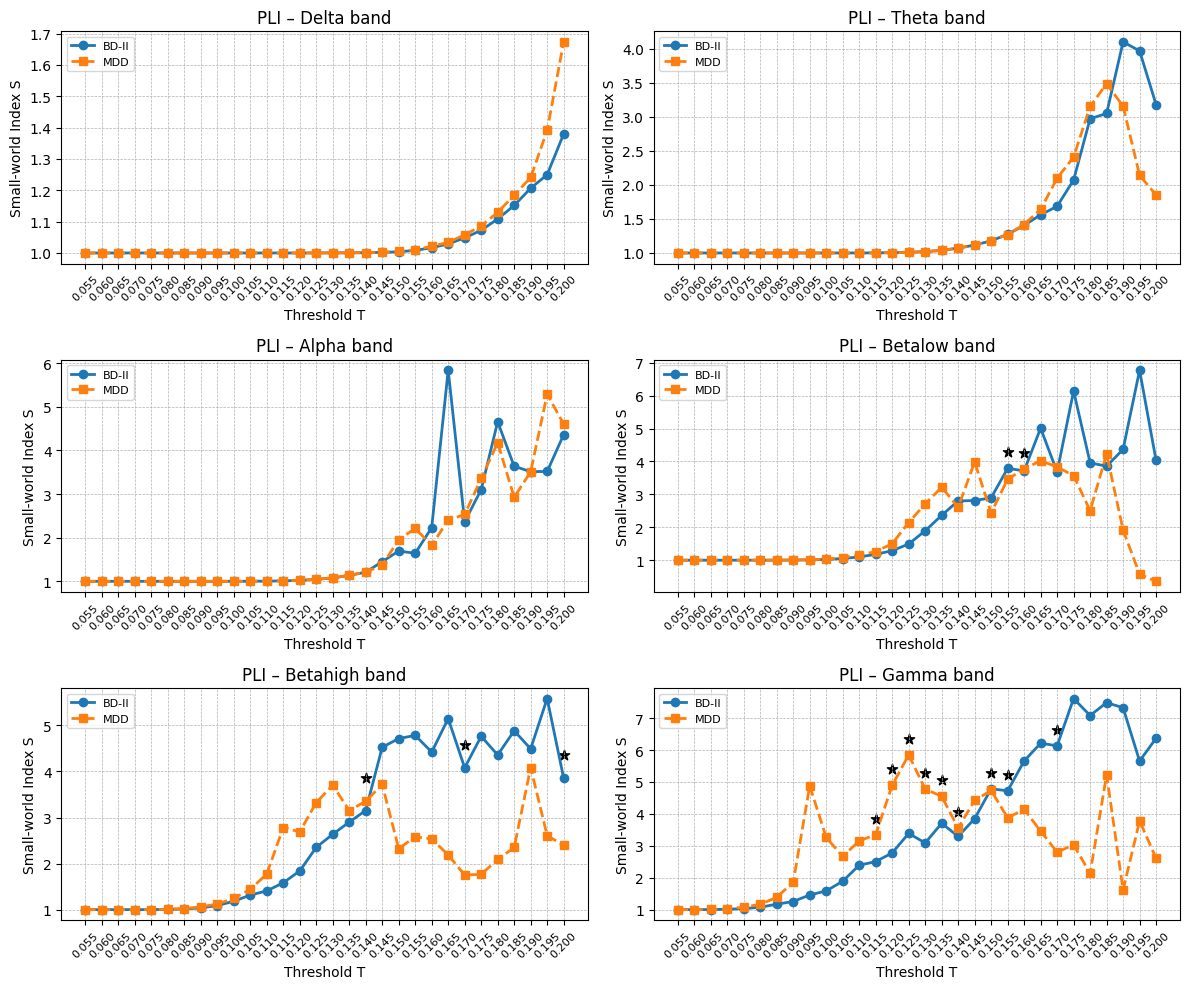

In [9]:
summary = {band: {} for band in freqs}
signif  = {band: [] for band in freqs}

for band in freqs:
    for T in thresholds:
        mb = metrics_BD[band][T]
        mm = metrics_MDD[band][T]
        if not mb['S'] or not mm['S']:
            summary[band][T] = None
            signif[band].append(False)
            continue

        # 平均值
        mS_b = np.mean(mb['S'])
        mS_m = np.mean(mm['S'])

        # t 檢定
        stat, p = ttest_ind(mb['S'], mm['S'], equal_var=False)
        flag = (p < 0.05)
        signif[band].append(flag)

        summary[band][T] = {
            'mean_S_BD':  mS_b,
            'mean_S_MDD': mS_m,
            't_stat':     stat,
            'p_val':      p
        }

# plot
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, band in zip(axes, freqs):
    x    = thresholds[10:40]
    y_bd = [summary[band][T]['mean_S_BD']  if summary[band][T] else np.nan for T in x]
    y_mdd = [summary[band][T]['mean_S_MDD'] if summary[band][T] else np.nan for T in x]
    sigs = signif[band]

    ax.plot(x, y_bd,  label='BD-II', linewidth=2, marker='o')
    ax.plot(x, y_mdd, linestyle='--', label='MDD', linewidth=2, marker='s')

    # 標示顯著點
    for xi, bd_i, mdd_i, sig in zip(x, y_bd, y_mdd, sigs):
        if sig:
            y_star = max(bd_i, mdd_i) + 0.5
            ax.scatter(xi, y_star, marker='*', color='black', s=60)

    ax.set_xticks(x)
    ax.set_xticklabels([f"{t:.3f}" for t in x], rotation=45, fontsize=8)
    ax.grid(True, which='major', linestyle='--', linewidth=0.5)

    ax.set_title(f'PLI – {band.capitalize()} band')
    ax.set_xlabel('Threshold T')
    ax.set_ylabel('Small-world Index S')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

##### STE

In [17]:
def load_pickle(path):
    with open(path, 'rb') as f:
        return pickle.load(f)

def vec2dirmat(vec, n_chan):
    mat = vec.reshape((n_chan, n_chan))
    np.fill_diagonal(mat, 0)
    return mat


root       = Path("../data")
BD_ste     = load_pickle(root / "STE" / "BD_ste_data.pkl")
MDD_ste    = load_pickle(root / "STE" / "MDD_ste_data.pkl")
freqs      = ["delta", "theta", "alpha", "betalow", "betahigh", "gamma"]
thresholds = np.arange(0.0005, 0.3, 0.0005)
n_rand     = 20

In [18]:
def compute_stage_metrics_ste(group_ste, freqs, thresholds, n_rand):
    n_chan = None
    metrics = {band: {} for band in freqs}

    for band in freqs:
        for T in thresholds:
            C_list = []; Cr_list = []
            L_list = []; Lr_list = []
            gamma_list = []; lam_list = []; S_list = []

            for subj in group_ste.values():
                X = subj[band]
                # 還原有向矩陣
                if X.ndim == 1:
                    if n_chan is None:
                        n_chan = int(np.sqrt(len(X)))
                    mat_dir = vec2dirmat(X, n_chan)
                else:
                    mat_dir = X
                    if n_chan is None:
                        n_chan = mat_dir.shape[0]

                # 取雙向中較強的連結值，再做無向閾值
                W = np.maximum(mat_dir, mat_dir.T)
                A = (W > T).astype(int)
                if A.sum() < 2:
                    continue

                # 原網路：聚類係數 C 與平均最短路徑長度 L
                G = nx.from_numpy_array(A)
                C = nx.average_clustering(G)
                dists = []
                for i, dist in nx.all_pairs_shortest_path_length(G):
                    dists.extend([d for j, d in dist.items() if j > i])
                if not dists:
                    continue
                L = np.mean(dists)

                # 隨機網路：平均聚類 Cr 與平均最短路徑 Lr
                m_edges = int(A.sum() / 2)
                Cr_subj, Lr_subj = [], []
                for _ in range(n_rand):
                    G_r = nx.gnm_random_graph(n_chan, m_edges)
                    Cr_subj.append(nx.average_clustering(G_r))
                    d_r = []
                    for i, dist in nx.all_pairs_shortest_path_length(G_r):
                        d_r.extend([d for j, d in dist.items() if j > i])
                    if d_r:
                        Lr_subj.append(np.mean(d_r))
                if not Cr_subj or not Lr_subj:
                    continue

                Cr = np.mean(Cr_subj)
                Lr = np.mean(Lr_subj)
                if Cr == 0 or Lr == 0:
                    continue

                # 小世界指數
                gamma = C / Cr
                lam   = L / Lr
                S     = gamma / lam

                C_list.append(C);   Cr_list.append(Cr)
                L_list.append(L);   Lr_list.append(Lr)
                gamma_list.append(gamma); lam_list.append(lam)
                S_list.append(S)

            metrics[band][T] = {
                'C':    C_list,   'Cr':   Cr_list,
                'L':    L_list,   'Lr':   Lr_list,
                'gamma':gamma_list,'lam':  lam_list,
                'S':    S_list
            }

    return metrics

# 計算 STE 指標
metrics_BD  = compute_stage_metrics_ste(BD_ste,  freqs, thresholds, n_rand)
metrics_MDD = compute_stage_metrics_ste(MDD_ste, freqs, thresholds, n_rand)


In [19]:
### save metrics
with open("../result_FA/svalue/STE/metrics_BD.pkl", 'wb') as f:
    pickle.dump(metrics_BD, f)
with open("../result_FA/svalue/STE/metrics_MDD.pkl", 'wb') as f:
    pickle.dump(metrics_MDD, f)

In [ ]:
### load metrics
with open("../result_FA/svalue/STE/metrics_BD.pkl", 'rb') as f:
    metrics_BD = pickle.load(f)
with open("../result_FA/svalue/STE/metrics_MDD.pkl", 'rb') as f:
    metrics_MDD = pickle.load(f)

c:\Users\NESS-Kuan\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


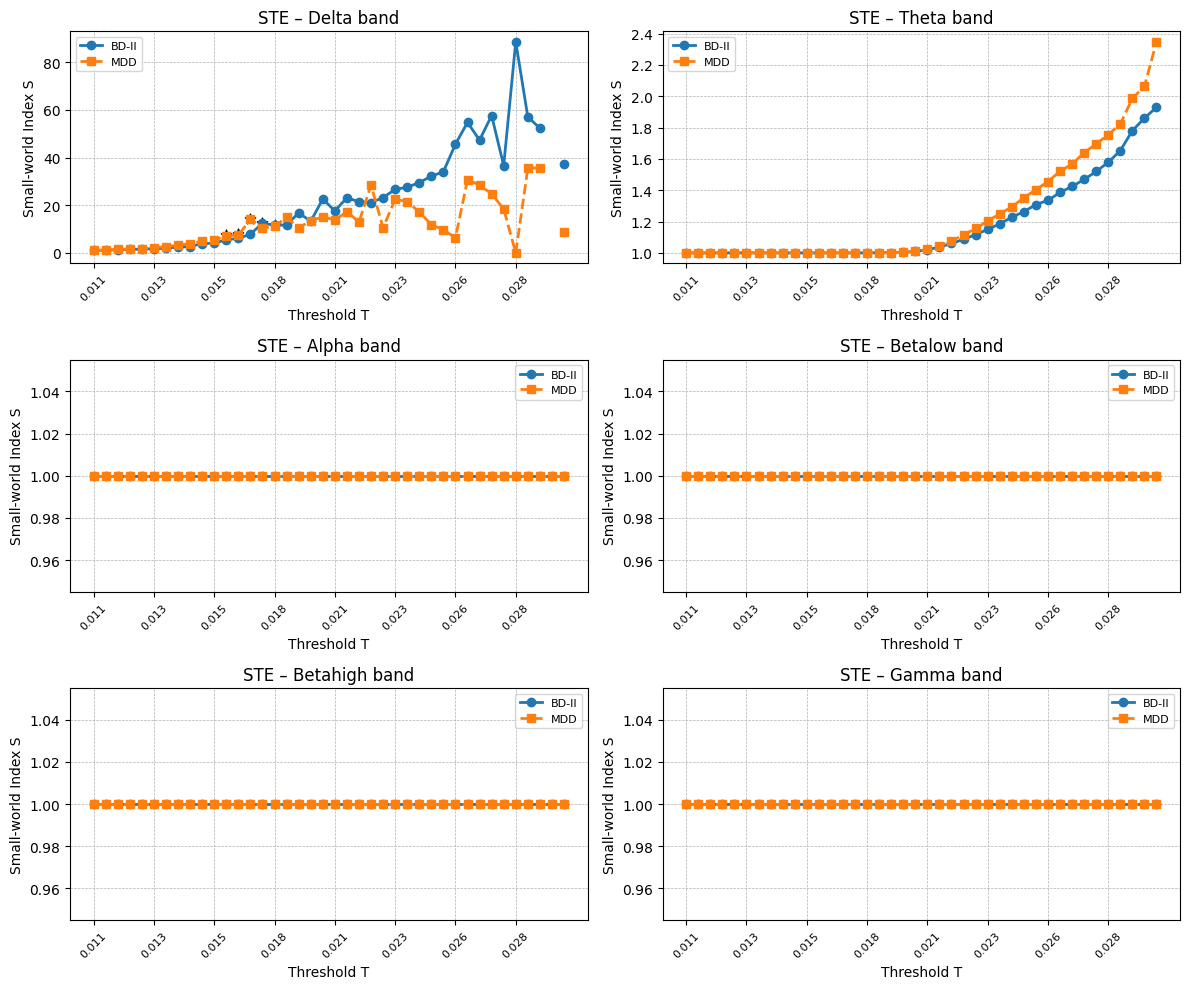

In [22]:
# 摘要統計與顯著性檢定
summary = {band: {} for band in freqs}
signif  = {band: [] for band in freqs}

for band in freqs:
    for T in thresholds:
        mb = metrics_BD[band][T]
        mm = metrics_MDD[band][T]
        if not mb['S'] or not mm['S']:
            summary[band][T] = None
            signif[band].append(False)
            continue

        # 計算群組平均 S
        mS_b = np.mean(mb['S'])
        mS_m = np.mean(mm['S'])
        # 非配對 t 檢定
        stat, p = ttest_ind(mb['S'], mm['S'], equal_var=False)
        flag = (p < 0.05)
        signif[band].append(flag)

        summary[band][T] = {
            'mean_S_BD':  mS_b,
            'mean_S_MDD': mS_m,
            't_stat':     stat,
            'p_val':      p
        }

# 繪圖：Small-world Index S vs Threshold
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, band in zip(axes, freqs):
    # 只取 thresholds[10:40] 做示範
    x     = thresholds[20:60]
    y_bd  = [summary[band][T]['mean_S_BD']  if summary[band][T] else np.nan for T in x]
    y_mdd = [summary[band][T]['mean_S_MDD'] if summary[band][T] else np.nan for T in x]
    sigs  = signif[band][10:40]

    ax.plot(x, y_bd,  label='BD-II', linewidth=2, marker='o')
    ax.plot(x, y_mdd, linestyle='--', label='MDD', linewidth=2, marker='s')

    # 標示顯著點
    for xi, bd_i, mdd_i, sig in zip(x, y_bd, y_mdd, sigs):
        if sig:
            y_star = max(bd_i, mdd_i) + 0.3
            ax.scatter(xi, y_star, marker='*', color='black', s=60)

    ax.set_xticks(x[::5])
    ax.set_xticklabels([f"{t:.3f}" for t in x[::5]], rotation=45, fontsize=8)
    ax.grid(True, which='major', linestyle='--', linewidth=0.5)

    ax.set_title(f'STE – {band.capitalize()} band')
    ax.set_xlabel('Threshold T')
    ax.set_ylabel('Small-world Index S')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()